# Evaluasi Multi-Seed LSTM Hybrid — STANDALONE

Satu file, jalankan dari atas ke bawah. Mengukur **variansi inisialisasi** dengan melatih LSTM Hybrid (target log-return) pada banyak seed, lalu melaporkan **rata-rata ± std** dibanding baseline Naive, Mean-7, dan SARIMA.

Atur `DATA_DIR` di Section 0 bila perlu.

## SECTION 0 — Setup

In [1]:
import os, random, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
warnings.filterwarnings('ignore')

DATA_DIR  = 'data'                       # <-- sesuaikan
DAILY_CSV = os.path.join(DATA_DIR, 'daily_sales.csv')

LOOK_BACK, HORIZON = 7, 1
UNITS, DROPOUT     = 24, 0.1
N_SEEDS            = 10                   # turunkan ke 5 utk uji cepat
print('Setup OK |', DAILY_CSV, '| ada?', os.path.exists(DAILY_CSV))

Setup OK | data\daily_sales.csv | ada? True


## SECTION 1 — Data, Fitur (target = log-return), Split

In [2]:
df = pd.read_csv(DAILY_CSV, parse_dates=['date'])
dfa = df[df['revenue'] > 0].copy().sort_values('date').reset_index(drop=True)

dfa['rev_log'] = np.log1p(dfa['revenue'])
dfa['logret']  = dfa['rev_log'].diff().fillna(0.0)        # TARGET
dfa['week_sin']  = np.sin(2*np.pi*dfa['week_of_year']/52)
dfa['week_cos']  = np.cos(2*np.pi*dfa['week_of_year']/52)
dfa['month_sin'] = np.sin(2*np.pi*dfa['month']/12)
dfa['month_cos'] = np.cos(2*np.pi*dfa['month']/12)
dfa['dow_sin']   = np.sin(2*np.pi*dfa['day_of_week']/5)
dfa['dow_cos']   = np.cos(2*np.pi*dfa['day_of_week']/5)

FEATURES = ['logret','week_sin','week_cos','month_sin','month_cos',
            'dow_sin','dow_cos','is_ramadan']                    # 'logret' = kolom 0

n = len(dfa); n_tr = int(n*0.70); n_va = int(n*0.15)
df_tr, df_va, df_te = dfa.iloc[:n_tr], dfa.iloc[n_tr:n_tr+n_va], dfa.iloc[n_tr+n_va:]
print(f'Train {len(df_tr)} | Val {len(df_va)} | Test {len(df_te)} hari aktif')

Train 219 | Val 46 | Test 48 hari aktif


## SECTION 2 — Scaling & Sequence

In [3]:
scaler = MinMaxScaler()
tr_s = scaler.fit_transform(df_tr[FEATURES].values)
va_s = scaler.transform(df_va[FEATURES].values)
te_s = scaler.transform(df_te[FEATURES].values)

def make_seq(arr, look_back, horizon, tcol=0):
    X, y = [], []
    for i in range(len(arr) - look_back - horizon + 1):
        X.append(arr[i:i+look_back]); y.append(arr[i+look_back:i+look_back+horizon, tcol])
    return np.array(X), np.array(y)

X_tr, y_tr = make_seq(tr_s, LOOK_BACK, HORIZON)
X_va, y_va = make_seq(va_s, LOOK_BACK, HORIZON)
X_te, y_te = make_seq(te_s, LOOK_BACK, HORIZON)
print('X_tr', X_tr.shape, '| X_va', X_va.shape, '| X_te', X_te.shape)

rng0, min0 = scaler.data_range_[0], scaler.data_min_[0]
def inv_logret(x): return np.asarray(x) * rng0 + min0

X_tr (212, 7, 8) | X_va (39, 7, 8) | X_te (41, 7, 8)


## SECTION 3 — Target Test, Metrik & Baseline (Naive, Mean-7)

In [4]:
rev_te    = df_te['revenue'].values
rev_true  = rev_te[LOOK_BACK:]                 # rev[t]
rev_prev  = rev_te[LOOK_BACK-1:-1]             # rev[t-1] aktual
naive_mae = np.mean(np.abs(np.diff(df_tr['revenue'].values)))

def smape(y, yh):
    d = (np.abs(y) + np.abs(yh)) / 2
    return np.mean(np.abs(y - yh) / np.where(d == 0, 1, d)) * 100

def metrics(y, yh):
    return {'RMSE': np.sqrt(mean_squared_error(y, yh)),
            'MAE' : mean_absolute_error(y, yh),
            'sMAPE': smape(y, yh),
            'MASE': mean_absolute_error(y, yh) / naive_mae}

y_naive = rev_prev
y_mean7 = np.array([rev_te[i-LOOK_BACK:i].mean() for i in range(LOOK_BACK, len(rev_te))])
m_naive = metrics(rev_true, y_naive)
m_mean7 = metrics(rev_true, y_mean7)
print('Naive  -> MAE Rp {:,.0f} | MASE {:.3f}'.format(m_naive['MAE'], m_naive['MASE']))
print('Mean-7 -> MAE Rp {:,.0f} | MASE {:.3f}'.format(m_mean7['MAE'], m_mean7['MASE']))

Naive  -> MAE Rp 519,841 | MASE 1.432
Mean-7 -> MAE Rp 647,263 | MASE 1.784


## SECTION 4 — Baseline SARIMA (rolling one-step)

In [5]:
# !pip install statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
rev_tr = df_tr['revenue'].values
hist_log = list(np.log1p(np.concatenate([rev_tr, df_va['revenue'].values])))
res_s = SARIMAX(hist_log, order=(1,1,1), seasonal_order=(1,0,0,5),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_pred = []
for actual in rev_te:
    sarima_pred.append(np.expm1(res_s.forecast(1)[0]))
    res_s = res_s.append([np.log1p(actual)], refit=False)
y_sarima = np.array(sarima_pred)[LOOK_BACK:]
m_sarima = metrics(rev_true, y_sarima)
print('SARIMA -> MAE Rp {:,.0f} | MASE {:.3f}'.format(m_sarima['MAE'], m_sarima['MASE']))

SARIMA -> MAE Rp 586,083 | MASE 1.615


## SECTION 5 — Latih N Seed (LSTM Hybrid)

In [6]:
def set_seed(s):
    os.environ['PYTHONHASHSEED'] = str(s)
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)

def build():
    m = Sequential([
        LSTM(UNITS, input_shape=(LOOK_BACK, len(FEATURES))),
        Dropout(DROPOUT),
        Dense(16, activation='relu'),
        Dense(HORIZON)
    ])
    m.compile(optimizer=Adam(5e-4), loss='mse', metrics=['mae'])
    return m

rows = []
for s in range(N_SEEDS):
    set_seed(s)
    cb = [EarlyStopping('val_loss', patience=20, restore_best_weights=True, verbose=0),
          ReduceLROnPlateau('val_loss', factor=0.5, patience=8, min_lr=1e-6, verbose=0)]
    mdl = build()
    mdl.fit(X_tr, y_tr, validation_data=(X_va, y_va),
            epochs=200, batch_size=16, callbacks=cb, verbose=0)
    logret_hat = inv_logret(mdl.predict(X_te, verbose=0).flatten())
    y_lstm = np.expm1(np.log1p(rev_prev) + logret_hat)
    r = metrics(rev_true, y_lstm); r['seed'] = s
    rows.append(r)
    print(f'seed {s:2d}  MAE Rp {r["MAE"]:>11,.0f} | RMSE Rp {r["RMSE"]:>11,.0f} | MASE {r["MASE"]:.3f}')

res = pd.DataFrame(rows)
print('\nSelesai melatih', N_SEEDS, 'model.')

seed  0  MAE Rp     607,371 | RMSE Rp     795,698 | MASE 1.674
seed  1  MAE Rp   1,048,967 | RMSE Rp   1,320,587 | MASE 2.891
seed  2  MAE Rp     610,569 | RMSE Rp     791,700 | MASE 1.682
seed  3  MAE Rp     685,684 | RMSE Rp     938,700 | MASE 1.889
seed  4  MAE Rp     628,808 | RMSE Rp     858,019 | MASE 1.733
seed  5  MAE Rp     703,063 | RMSE Rp     954,287 | MASE 1.937
seed  6  MAE Rp     635,780 | RMSE Rp     892,612 | MASE 1.752
seed  7  MAE Rp     495,527 | RMSE Rp     703,721 | MASE 1.365
seed  8  MAE Rp     614,390 | RMSE Rp     857,560 | MASE 1.693
seed  9  MAE Rp     647,023 | RMSE Rp     862,751 | MASE 1.783

Selesai melatih 10 model.


## SECTION 6 — Ringkasan: mean ± std & tingkat keberhasilan

In [7]:
print('=== LSTM Hybrid — agregat', N_SEEDS, 'seed ===')
for col in ['MAE','RMSE','sMAPE','MASE']:
    mu, sd = res[col].mean(), res[col].std()
    unit = 'Rp ' if col in ('MAE','RMSE') else ''
    print(f'{col:6s}: {unit}{mu:,.2f}  ±  {unit}{sd:,.2f}   '
          f'(min {res[col].min():,.2f} | max {res[col].max():,.2f})')

win_naive  = (res['MAE'] < m_naive['MAE'] ).mean() * 100
win_sarima = (res['MAE'] < m_sarima['MAE']).mean() * 100
print(f'\nLSTM < Naive  : {win_naive:.0f}% seed  (MAE Naive  Rp {m_naive["MAE"]:,.0f})')
print(f'LSTM < SARIMA : {win_sarima:.0f}% seed  (MAE SARIMA Rp {m_sarima["MAE"]:,.0f})')

summary = pd.DataFrame({
    'Model'   : ['Naive (kemarin)','SARIMA','Mean-7',
                 f'LSTM Hybrid (mean±std, n={N_SEEDS})'],
    'MAE (Rp)': [f"{m_naive['MAE']:,.0f}", f"{m_sarima['MAE']:,.0f}", f"{m_mean7['MAE']:,.0f}",
                 f"{res['MAE'].mean():,.0f} ± {res['MAE'].std():,.0f}"],
    'MASE'    : [f"{m_naive['MASE']:.3f}", f"{m_sarima['MASE']:.3f}", f"{m_mean7['MASE']:.3f}",
                 f"{res['MASE'].mean():.3f} ± {res['MASE'].std():.3f}"],
})
print('\n', summary.to_string(index=False))

=== LSTM Hybrid — agregat 10 seed ===
MAE   : Rp 667,718.12  ±  Rp 145,023.54   (min 495,527.05 | max 1,048,966.81)
RMSE  : Rp 897,563.41  ±  Rp 165,803.80   (min 703,720.96 | max 1,320,587.48)
sMAPE : 38.06  ±  3.96   (min 29.16 | max 44.63)
MASE  : 1.84  ±  0.40   (min 1.37 | max 2.89)

LSTM < Naive  : 10% seed  (MAE Naive  Rp 519,841)
LSTM < SARIMA : 10% seed  (MAE SARIMA Rp 586,083)

                        Model          MAE (Rp)          MASE
             Naive (kemarin)           519,841         1.432
                      SARIMA           586,083         1.615
                      Mean-7           647,263         1.784
LSTM Hybrid (mean±std, n=10) 667,718 ± 145,024 1.840 ± 0.400


## SECTION 7 — Distribusi MAE antar-seed

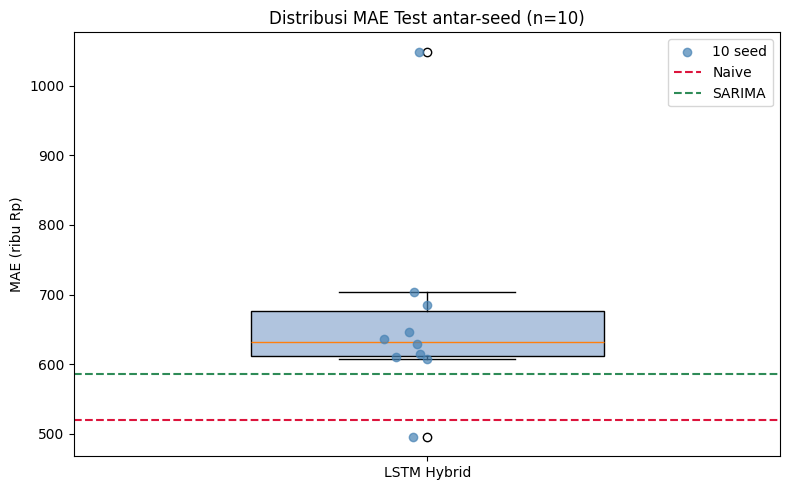

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
ax.boxplot(res['MAE']/1e3, vert=True, widths=0.5,
           patch_artist=True, boxprops=dict(facecolor='lightsteelblue'))
ax.scatter(np.random.normal(1, 0.04, len(res)), res['MAE']/1e3,
           color='steelblue', alpha=.7, zorder=3, label=f'{N_SEEDS} seed')
ax.axhline(m_naive['MAE']/1e3,  color='crimson',  ls='--', label='Naive')
ax.axhline(m_sarima['MAE']/1e3, color='seagreen', ls='--', label='SARIMA')
ax.set_xticks([1]); ax.set_xticklabels(['LSTM Hybrid'])
ax.set_ylabel('MAE (ribu Rp)'); ax.set_title(f'Distribusi MAE Test antar-seed (n={N_SEEDS})')
ax.legend(); plt.tight_layout(); plt.show()